In [51]:
import pandas as pd
import spacy
from nltk.corpus import stopwords
import nltk
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import AdaBoostClassifier, VotingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_curve, auc
from sklearn.preprocessing import LabelBinarizer
import numpy as np
from nltk.tokenize import sent_tokenize
import re

In [5]:
nltk.download('stopwords')
stop_words = set(stopwords.words('russian'))

nlp = spacy.load("ru_core_news_sm")

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\RobotComp.ru\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [98]:
df = pd.read_csv("rusentiment_random_posts.csv")[:15000]

rows = []


In [16]:
for idx, row in df.iterrows():
    text = str(row['text'])
    label = row['label']
    
    doc = nlp(text)
    
    tokens = [token for token in doc if token.is_alpha or token.is_digit]
    num_tokens = len(tokens)
    
    # Существительные
    nouns_pos = [i for i, token in enumerate(tokens, start=1) if token.pos_ == 'NOUN']
    num_nouns = len(nouns_pos)
    avg_nouns_pos = sum(nouns_pos)/num_nouns if num_nouns > 0 else 0
    
    # Местоимения (PRON)
    pron_pos = [i for i, token in enumerate(tokens, start=1) if token.pos_ == 'PRON']
    num_pron = len(pron_pos)
    avg_pron_pos = sum(pron_pos)/num_pron if num_pron > 0 else 0
    
    rows.append({
        'label': label,
        'text': text,
        'num_elements': num_tokens,
        'avg_pos_N': avg_nouns_pos,
        'num_N': num_nouns,
        'avg_pos_PRON': avg_pron_pos,
        'num_PRON': num_pron
    })

In [12]:
print(rows[:10])

[{'label': 'negative', 'text': 'А попа подозревала давно,что ты с кавказа..перестану общаться с тобой', 'nouns': 3, 'verbs': 2, 'adjectives': 0, 'adverbs': 1, 'interjections': 0, 'stopwords': 5, 'token_count': 12}, {'label': 'speech', 'text': 'З прошедшим Днем Ангела))))))))', 'nouns': 0, 'verbs': 1, 'adjectives': 0, 'adverbs': 0, 'interjections': 0, 'stopwords': 0, 'token_count': 4}, {'label': 'skip', 'text': 'Два дня до отлёта с острова!!!!!!!', 'nouns': 3, 'verbs': 0, 'adjectives': 0, 'adverbs': 0, 'interjections': 0, 'stopwords': 3, 'token_count': 6}, {'label': 'negative', 'text': 'Блин, почему эта жизнь столь не справедлива ((((', 'nouns': 1, 'verbs': 0, 'adjectives': 1, 'adverbs': 2, 'interjections': 0, 'stopwords': 1, 'token_count': 7}, {'label': 'skip', 'text': 'где еще встречать свой день рождения как не на кладбище))))', 'nouns': 3, 'verbs': 1, 'adjectives': 0, 'adverbs': 2, 'interjections': 0, 'stopwords': 5, 'token_count': 10}, {'label': 'neutral', 'text': 'Решите уравнение

In [75]:
df_features = pd.DataFrame(rows)
df_features = df_features.fillna(0)
df_features = df_features[:12000]
df_features.info()
X = df_features[['nouns','verbs','adjectives','adverbs','interjections','stopwords','token_count']]
y = df_features['label']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=123, stratify=y
)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 14 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   label          12000 non-null  object 
 1   text           12000 non-null  object 
 2   nouns          12000 non-null  float64
 3   verbs          12000 non-null  float64
 4   adjectives     12000 non-null  float64
 5   adverbs        12000 non-null  float64
 6   interjections  12000 non-null  float64
 7   stopwords      12000 non-null  float64
 8   token_count    12000 non-null  float64
 9   num_elements   12000 non-null  float64
 10  avg_pos_N      12000 non-null  float64
 11  num_N          12000 non-null  float64
 12  avg_pos_PRON   12000 non-null  float64
 13  num_PRON       12000 non-null  float64
dtypes: float64(12), object(2)
memory usage: 1.3+ MB


In [76]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [77]:
knn = KNeighborsClassifier(n_neighbors=5)

logreg = LogisticRegression(
    max_iter=5000,
    solver="saga",
    tol=1e-3,
    class_weight="balanced"
)

svc = LinearSVC(
    class_weight="balanced"
)

ada = AdaBoostClassifier(estimator=logreg, n_estimators=20, random_state=42)

voting = VotingClassifier(
    estimators=[("knn", knn), ("logreg", logreg), ("svc", svc)],
    voting="hard"
)

In [92]:
models = {
    "KNN": knn,
    "LogisticRegression": logreg,
    "LinearSVC": svc,
    "AdaBoost_LogReg": ada,
    "HardVoting": voting
}

In [93]:

results = {}

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    
    results[name] = {
        "accuracy": accuracy_score(y_test, y_pred),
        "f1": f1_score(y_test, y_pred, average="weighted", zero_division=0),
        "precision": precision_score(y_test, y_pred, average="weighted", zero_division=0),
        "recall": recall_score(y_test, y_pred, average="weighted", zero_division=0),
    }

In [80]:
for name, metrics in results.items():
    print(f"=== {name} ===")
    print("Accuracy :", metrics["accuracy"])
    print("F1       :", metrics["f1"])
    print("Precision:", metrics["precision"])
    print("Recall   :", metrics["recall"])
    print()

=== KNN ===
Accuracy : 0.33375
F1       : 0.3128371956528648
Precision: 0.31422620967391457
Recall   : 0.33375

=== LogisticRegression ===
Accuracy : 0.25083333333333335
F1       : 0.238023693240602
Precision: 0.2903349698955899
Recall   : 0.25083333333333335

=== LinearSVC ===
Accuracy : 0.35125
F1       : 0.28545280767297676
Precision: 0.29607876084893214
Recall   : 0.35125

=== AdaBoost_LogReg ===
Accuracy : 0.29125
F1       : 0.2727667764118987
Precision: 0.2964886977726478
Recall   : 0.29125

=== HardVoting ===
Accuracy : 0.33625
F1       : 0.2989990531625351
Precision: 0.3102649530327001
Recall   : 0.33625



In [73]:
def plot_macro_roc(models, X_test_scaled, y_test, label, color_prefix=""):
    from sklearn.preprocessing import label_binarize
    classes = sorted(df_features['label'].unique())
    y_test_bin = label_binarize(y_test, classes=classes)
    n_classes = len(classes)

    for name, model in models.items():

        if hasattr(model, "predict_proba"):
            y_score = model.predict_proba(X_test_scaled)

        elif hasattr(model, "decision_function"):
            y_score = model.decision_function(X_test_scaled)

        else:
            preds = model.predict(X_test_scaled)
            y_score = label_binarize(preds, classes=classes)

        fpr_list = []
        tpr_list = []
        roc_auc_list = []

        for i in range(n_classes):
            fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
            fpr_list.append(fpr)
            tpr_list.append(tpr)
            roc_auc_list.append(auc(fpr, tpr))

        all_fpr = np.unique(np.concatenate([f for f in fpr_list]))
        mean_tpr = np.zeros_like(all_fpr)

        for i in range(n_classes):
            mean_tpr += np.interp(all_fpr, fpr_list[i], tpr_list[i])

        mean_tpr /= n_classes
        macro_auc = auc(all_fpr, mean_tpr)

        plt.plot(
            all_fpr, mean_tpr,
            lw=2,
            label=f"{label} | {name} (AUC={macro_auc:.3f})"
        )

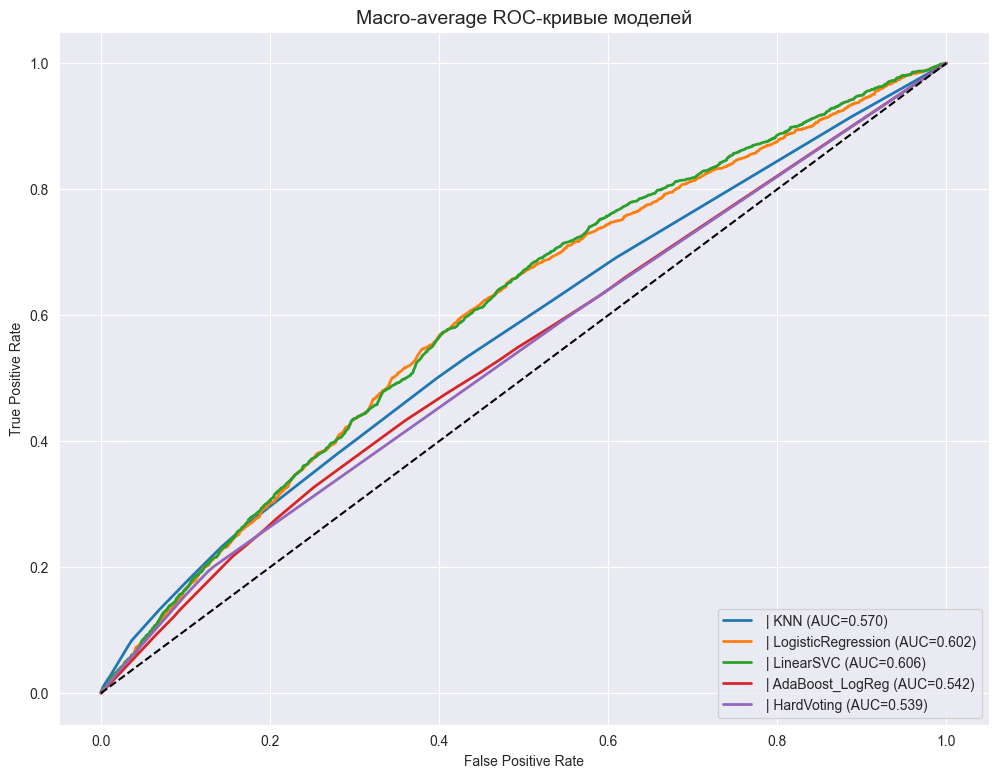

In [81]:
plt.figure(figsize=(12, 9))
plot_macro_roc(models, X_test_scaled, y_test, label="")
plt.plot([0, 1], [0, 1], 'k--')

plt.title("ROC-кривые моделей", fontsize=14)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()


In [58]:
nltk.download("punkt")
nltk.download("punkt_tab")  

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\RobotComp.ru\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\RobotComp.ru\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt_tab.zip.


True

In [59]:
def extract_syntax_features(text):

    # Предложения
    sentences = sent_tokenize(text)
    num_sentences = max(len(sentences), 1)

    # Слова
    words = re.findall(r"\w+", text.lower())
    num_words = max(len(words), 1)

    # Средняя длина предложения
    avg_sentence_length = num_words / num_sentences

    # Знаки препинания
    punctuation_list = re.findall(r"[.,!?;:\-—()\"«»]", text)
    punct_count = len(punctuation_list)

    # Плотность пунктуации
    punct_density = punct_count / num_words

    # Сложность: число запятых
    comma_count = text.count(',')

    # Позиции запятых (начало=0, середина=1, конец=2)
    comma_positions = []
    for pos in [text.find(","), text.rfind(",")]:
        if pos == -1:
            comma_positions.append(0)
        elif pos < len(text) * 0.33:
            comma_positions.append(0)
        elif pos < len(text) * 0.66:
            comma_positions.append(1)
        else:
            comma_positions.append(2)

    return {
        "avg_sentence_length": avg_sentence_length,
        "punct_count": punct_count,
        "punct_density": punct_density,
        "comma_count": comma_count,
        "comma_first_pos": comma_positions[0],
        "comma_last_pos": comma_positions[1]
    }

In [82]:
syntax_df = df["text"].apply(extract_syntax_features).apply(pd.Series)[:12000]

X_full = pd.concat([X, syntax_df], axis=1)
X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X_full, y, test_size=0.2, random_state=123
)
X_full.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   nouns                12000 non-null  float64
 1   verbs                12000 non-null  float64
 2   adjectives           12000 non-null  float64
 3   adverbs              12000 non-null  float64
 4   interjections        12000 non-null  float64
 5   stopwords            12000 non-null  float64
 6   token_count          12000 non-null  float64
 7   avg_sentence_length  12000 non-null  float64
 8   punct_count          12000 non-null  float64
 9   punct_density        12000 non-null  float64
 10  comma_count          12000 non-null  float64
 11  comma_first_pos      12000 non-null  float64
 12  comma_last_pos       12000 non-null  float64
dtypes: float64(13)
memory usage: 1.2 MB


In [83]:
scaler = StandardScaler()
X_train_scaled2= scaler.fit_transform(X_train2)
X_test_scaled2 = scaler.transform(X_test2)


In [87]:
knn2 = KNeighborsClassifier(n_neighbors=5)

logreg2 = LogisticRegression(
    max_iter=5000,
    solver="saga",
    tol=1e-3,
    class_weight="balanced"
)

svc2 = LinearSVC(
    class_weight="balanced"
)

ada2 = AdaBoostClassifier(estimator=logreg2, n_estimators=20, random_state=42)

voting2 = VotingClassifier(
    estimators=[("knn", knn2), ("logreg", logreg2), ("svc", svc2)],
    voting="hard"
)
models2 = {
    "KNN": knn2,
    "LogisticRegression": logreg2,
    "LinearSVC": svc2,
    "AdaBoost_LogReg": ada2,
    "HardVoting": voting2
}

In [88]:
results_syntax = {}

for name, model in models2.items():
    model.fit(X_train_scaled2, y_train2)
    y_pred = model.predict(X_test_scaled2)

    results_syntax[name] = {
        "accuracy": accuracy_score(y_test2, y_pred),
        "f1": f1_score(y_test2, y_pred, average="weighted", zero_division=0),
        "precision": precision_score(y_test2, y_pred, average="weighted", zero_division=0),
        "recall": recall_score(y_test2, y_pred, average="weighted", zero_division=0),
    }

In [89]:
print("\n=== Сравнение качества (до после синтаксиcки) ===\n")
for model_name in results:
    print(f"--- {model_name} ---")
    print("Accuracy :", results[model_name]["accuracy"], " ", results_syntax[model_name]["accuracy"])
    print("F1       :", results[model_name]["f1"],       " ", results_syntax[model_name]["f1"])
    print("Precision:", results[model_name]["precision"], " ", results_syntax[model_name]["precision"])
    print("Recall   :", results[model_name]["recall"],    " ", results_syntax[model_name]["recall"])
    print()


=== Сравнение качества (до после синтаксиcки) ===

--- KNN ---
Accuracy : 0.33375   0.355
F1       : 0.3128371956528648   0.3273494298199425
Precision: 0.31422620967391457   0.3237730202499003
Recall   : 0.33375   0.355

--- LogisticRegression ---
Accuracy : 0.25083333333333335   0.3545833333333333
F1       : 0.238023693240602   0.34694374034677167
Precision: 0.2903349698955899   0.35540110280192794
Recall   : 0.25083333333333335   0.3545833333333333

--- LinearSVC ---
Accuracy : 0.35125   0.3908333333333333
F1       : 0.28545280767297676   0.3476566965799675
Precision: 0.29607876084893214   0.34832038666547455
Recall   : 0.35125   0.3908333333333333

--- AdaBoost_LogReg ---
Accuracy : 0.29125   0.3475
F1       : 0.2727667764118987   0.32923524155240674
Precision: 0.2964886977726478   0.34666799157896105
Recall   : 0.29125   0.3475

--- HardVoting ---
Accuracy : 0.33625   0.38083333333333336
F1       : 0.2989990531625351   0.3485771204588215
Precision: 0.3102649530327001   0.350973013

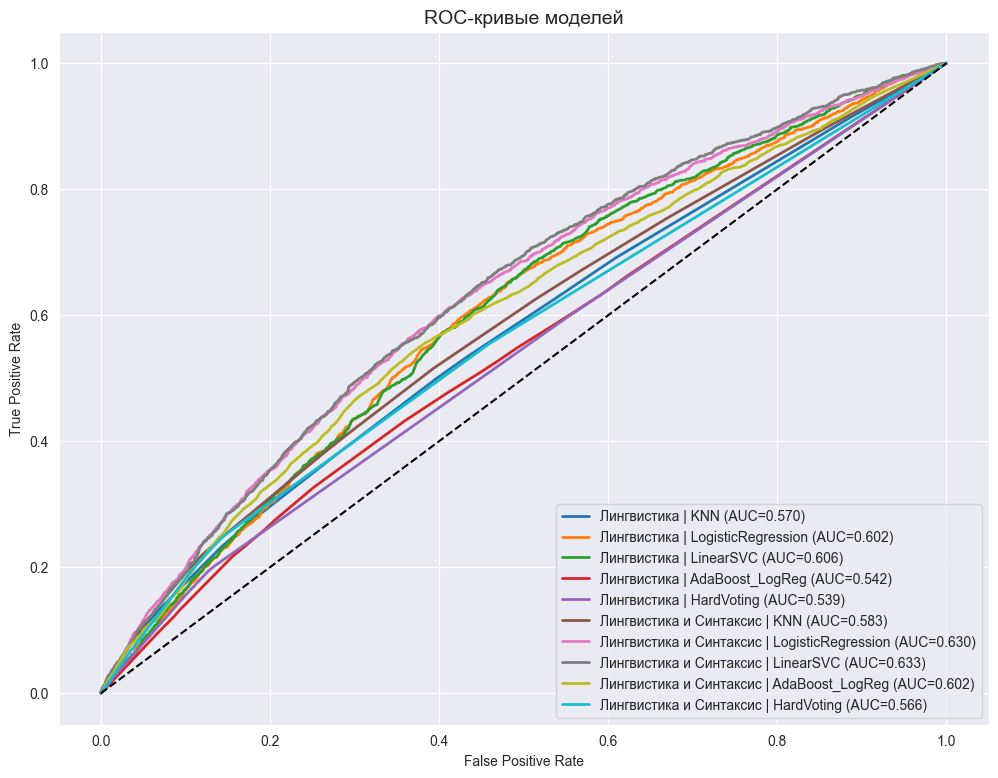

In [95]:
plt.figure(figsize=(12, 9))

plot_macro_roc(models, X_test_scaled, y_test, label="Лингвистика")

plot_macro_roc(models2, X_test_scaled2, y_test2, label="Лингвистика и Синтаксис")

# Диагональная линия — случайный классификатор
plt.plot([0, 1], [0, 1], 'k--')

plt.title("ROC-кривые моделей", fontsize=14)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

In [96]:
import re
import numpy as np
from collections import Counter
from math import log2

def extract_lexico_stylistic_features(text):
    # --- Токены ---
    words = re.findall(r"\w+", text.lower())
    num_words = max(len(words), 1)

    freq = Counter(words)
    unique_words = len(freq)

    # Индекс дистрибуции (распределённость слов)
    # Чем равномернее распределены частоты, тем выше индекс
    freqs = np.array(list(freq.values()))
    distribution_index = freqs.std() / (freqs.mean() + 1e-6)

    # Индекс итерации (повторяемость)
    # Доля слов, встречающихся ≥ 2 раз
    repeats = sum(1 for w, c in freq.items() if c >= 2)
    iteration_index = repeats / unique_words

    # Индекс исключительности (уникальность)
    # Доля слов, встречающихся только 1 раз
    hapax = sum(1 for w, c in freq.items() if c == 1)
    exclusivity_index = hapax / unique_words

    #  Индекс предсказуемости (энтропия)
    p = np.array([c / num_words for c in freq.values()])
    entropy = -np.sum(p * np.log2(p))
    max_entropy = log2(unique_words + 1)
    predictability_index = entropy / (max_entropy + 1e-6)

    # Индекс плотности текста
    # Количество содержательных слов (не повторяющихся) / общее число слов
    text_density = unique_words / num_words

    return {
        "distribution_index": float(distribution_index),
        "iteration_index": float(iteration_index),
        "exclusivity_index": float(exclusivity_index),
        "predictability_index": float(predictability_index),
        "text_density": float(text_density)
    }


In [99]:
features_list = []

for idx, row in df.iterrows():
    text = str(row["text"])
    label = row["label"]

    doc = nlp(text)

    # Базовые лингвистические признаки
    tokens = [token.text.lower() for token in doc if token.is_alpha]
    pos_tags = [token.pos_ for token in doc if token.is_alpha]

    ling_features = {
        "nouns": pos_tags.count("NOUN"),
        "verbs": pos_tags.count("VERB"),
        "adjectives": pos_tags.count("ADJ"),
        "adverbs": pos_tags.count("ADV"),
        "interjections": pos_tags.count("INTJ"),
        "stopwords": sum(1 for t in tokens if t in stop_words),
        "token_count": len(tokens)
    }

    # Лексико-стилистические признаки
    lex_features = extract_lexico_stylistic_features(text)

    # Объединяем все признаки
    all_features = {"label": label, "text": text}
    all_features.update(ling_features)
    all_features.update(lex_features)

    features_list.append(all_features)

df_features_n = pd.DataFrame(features_list)
df_features_n.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   label                 15000 non-null  object 
 1   text                  15000 non-null  object 
 2   nouns                 15000 non-null  int64  
 3   verbs                 15000 non-null  int64  
 4   adjectives            15000 non-null  int64  
 5   adverbs               15000 non-null  int64  
 6   interjections         15000 non-null  int64  
 7   stopwords             15000 non-null  int64  
 8   token_count           15000 non-null  int64  
 9   distribution_index    15000 non-null  float64
 10  iteration_index       15000 non-null  float64
 11  exclusivity_index     15000 non-null  float64
 12  predictability_index  15000 non-null  float64
 13  text_density          15000 non-null  float64
dtypes: float64(5), int64(7), object(2)
memory usage: 1.6+ MB


In [100]:
df_features_n = df_features_n.fillna(0)
df_features_n = df_features_n[:12000]
df_features_n.info()
X = df_features[['nouns', 'verbs', 'adjectives', 'adverbs', 'interjections', 'stopwords', 'token_count']]
y = df_features['label']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=123, stratify=y
)
scaler = StandardScaler()
X_train_scaled3 = scaler.fit_transform(X_train)
X_test_scaled3 = scaler.transform(X_test)
knn3 = KNeighborsClassifier(n_neighbors=5)

logreg3 = LogisticRegression(
    max_iter=5000,
    solver="saga",
    tol=1e-3,
    class_weight="balanced"
)

svc3 = LinearSVC(
    class_weight="balanced"
)

ada3 = AdaBoostClassifier(estimator=logreg3, n_estimators=20, random_state=42)

voting3 = VotingClassifier(
    estimators=[("knn", knn3), ("logreg", logreg3), ("svc", svc3)],
    voting="hard"
)
models3 = {
    "KNN": knn3,
    "LogisticRegression": logreg3,
    "LinearSVC": svc3,
    "AdaBoost_LogReg": ada3,
    "HardVoting": voting3
}

results = {}

for name, model in models3.items():
    model.fit(X_train_scaled3, y_train)
    y_pred = model.predict(X_test_scaled3)

    results[name] = {
        "accuracy": accuracy_score(y_test, y_pred),
        "f1": f1_score(y_test, y_pred, average="weighted", zero_division=0),
        "precision": precision_score(y_test, y_pred, average="weighted", zero_division=0),
        "recall": recall_score(y_test, y_pred, average="weighted", zero_division=0),
    }
for name, metrics in results.items():
    print(f"=== {name} ===")
    print("Accuracy :", metrics["accuracy"])
    print("F1       :", metrics["f1"])
    print("Precision:", metrics["precision"])
    print("Recall   :", metrics["recall"])
    print()
    



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   label                 12000 non-null  object 
 1   text                  12000 non-null  object 
 2   nouns                 12000 non-null  int64  
 3   verbs                 12000 non-null  int64  
 4   adjectives            12000 non-null  int64  
 5   adverbs               12000 non-null  int64  
 6   interjections         12000 non-null  int64  
 7   stopwords             12000 non-null  int64  
 8   token_count           12000 non-null  int64  
 9   distribution_index    12000 non-null  float64
 10  iteration_index       12000 non-null  float64
 11  exclusivity_index     12000 non-null  float64
 12  predictability_index  12000 non-null  float64
 13  text_density          12000 non-null  float64
dtypes: float64(5), int64(7), object(2)
memory usage: 1.3+ MB
=== KNN ===
A

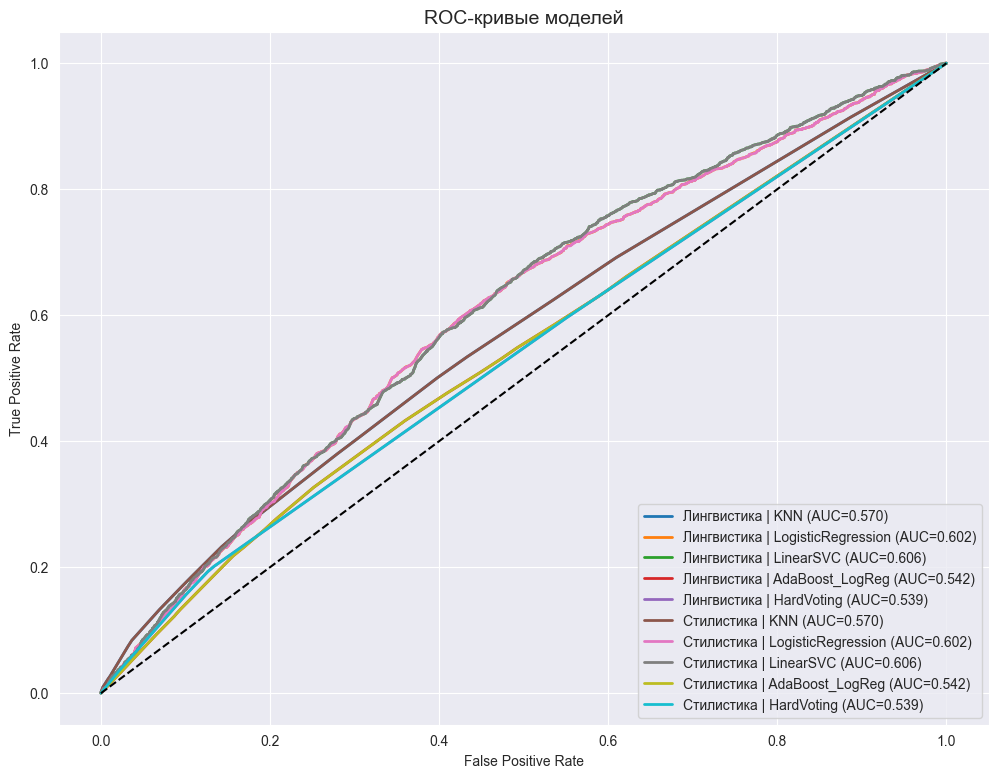

In [102]:
plt.figure(figsize=(12, 9))

plot_macro_roc(models, X_test_scaled, y_test, label="Лингвистика")

#plot_macro_roc(models2, X_test_scaled2, y_test2, label="Лингвистика и Синтаксис")
plot_macro_roc(models3, X_test_scaled3, y_test, label="Стилистика")

# Диагональная линия — случайный классификатор
plt.plot([0, 1], [0, 1], 'k--')

plt.title("ROC-кривые моделей", fontsize=14)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()